#### Cleaning messy_customer_sales_data.csv

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('messy_customer_sales_data.csv')
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul\nWilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,1217591682,India
1,CUST5957,Jason\nThomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,5029934836,India
2,CUST3754,Brittney\nMartinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.com,7266375345,NaN
3,CUST2934,Brenda\nPierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.com,1393438606,india
4,CUST5683,Matthew\nCarroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.com,1820016091,india
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,CUST10767,Robert\nLewis,female,35.0 years,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.com,1767847165,India
10196,NaN,Sarah\nEvans,M,53.0,bangalore,2023-12-31,2025-05-07,11639.0,NaN,msdennis@example.com,7066696685,India
10197,CUST2992,Emily\nWhite,Female,29.6,Ahmedabad,2024-12-09,2024-05-21,44243.3,NaN,barrycrane89@example.com,4785467602,India
10198,CUST4159,Matthew\nThompson,m,NaN,Lucknow,2020-12-17,2023-07-24,13815.9,7.0,barrycrane211@example.com,4518507319,India


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9178 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9177 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9189 non-null   object 
 7   Purchase_Amount     9178 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


In [5]:
df.describe()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9.178000e+03,9177.000000,1.020000e+04
mean,3.827918e+04,5.511278,5.438587e+09
std,2.691517e+05,2.862382,2.626029e+09
min,-4.730000e+02,1.000000,9.013396e+08
25%,1.651135e+04,3.000000,3.196358e+09
50%,2.768155e+04,5.000000,5.452322e+09
75%,3.899185e+04,8.000000,7.685367e+09
max,9.279836e+06,10.000000,9.999188e+09


In [6]:
df.describe().round()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9178.0,9177.0,1.020000e+04
mean,38279.0,6.0,5.438587e+09
std,269152.0,3.0,2.626029e+09
min,-473.0,1.0,9.013396e+08
25%,16511.0,3.0,3.196358e+09
50%,27682.0,5.0,5.452322e+09
75%,38992.0,8.0,7.685367e+09
max,9279836.0,10.0,9.999188e+09


Huge difference between min and max so remove outliers

In [7]:
# missing values
df.isnull().sum()

Customer_ID           1022
Name                     0
Gender                1023
Age                    951
City                  1016
Signup_Date              0
Last_Purchase_Date    1011
Purchase_Amount       1022
Feedback_Score        1023
Email                    0
Phone_Number             0
Country                732
dtype: int64

In [8]:
# percentage of missing values
df.isnull().sum()/len(df)*100

Customer_ID           10.019608
Name                   0.000000
Gender                10.029412
Age                    9.323529
City                   9.960784
Signup_Date            0.000000
Last_Purchase_Date     9.911765
Purchase_Amount       10.019608
Feedback_Score        10.029412
Email                  0.000000
Phone_Number           0.000000
Country                7.176471
dtype: float64

In [9]:
df.shape

(10200, 12)

In [10]:
df.dropna().shape

(4604, 12)

so dropping data results in loss of huge data

In [12]:
df[df.duplicated()]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country


In [13]:
df['Customer_ID'].value_counts().head()

Customer_ID
CUST8381    6
CUST3248    6
CUST9856    6
CUST2106    6
CUST4438    6
Name: count, dtype: int64

In [14]:
df[df['Customer_ID'] == 'CUST8381']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
731,CUST8381,Emily\nAnderson,male,69.3,Chennai,2022-07-26,2024-02-29,31793.2,8.0,tara39563@example.com,6179733614,india
749,CUST8381,Brittney\nThomas,FEMALE,NaN,lucknow,2022-12-25,2025-05-08,26061.5,NaN,owensanthony914@example.com,3960829477,INDIA
1370,CUST8381,Christopher\nClark,Female,34.5,NaN,2023-01-10,2021-08-26,NaN,4.0,denise84933@example.com,6666755845,INDIA
2393,CUST8381,John\nMartinez,MALE,61.8,NaN,2020-11-01,2023-12-15,41282.1,2.0,denise84271@yahoo.com,9574072256,india
3877,CUST8381,Daniel\nLewis,male,45.2,Lucknow,2021-09-12,NaN,15525.0,10.0,owensanthony534@example.com,5712839774,NaN
10008,CUST8381,Amanda\nCarroll,male,60.7,Pune,2021-02-05,NaN,30554.0,9.0,denise84498@outlook.com,9361666236,india


In [15]:
df[df['Customer_ID'] == 'CUST3248']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
1268,CUST3248,David\nTaylor,male,68.9 years,hyderabad,2019-09-08,2021-07-11,11181.4,6.0,berrynancy260@outlook.com,2330571126,IN
2913,CUST3248,Michael\nThompson,m,28.3,MUMBAI,2019-02-08,2023-11-27,19614.9,NaN,msdennis757@outlook.com,7325831090,india
3133,CUST3248,Matthew\nEvans,m,44.3,Kolkata,2023-12-12,2023-04-30,9824.6,5.0,msdennis776@yahoo.com,8093465105,India
5200,CUST3248,Christopher\nBrown,MALE,52.8,Jaipur,2020-02-26,NaN,31130.1,10.0,msdennis348@hotmail.com,7935918477,India
5748,CUST3248,Jessica\nTaylor,Female,37.7,LUCKNOW,2021-06-18,2022-06-18,49939.9,3.0,denise84142@yahoo.com,3470430631,India
8124,CUST3248,Jennifer\nTaylor,FEMALE,44.2,BANGALORE,2023-09-05,2023-10-14,12857.0,10.0,owensanthony259@gmail.com,2158112284,India


In [16]:
# unique values present in categorical columns
for col in df.columns:
    if df[col].nunique() < 20:
        print(df[col].value_counts())
        print('-'*50)

Gender
F         1386
m         1368
M         1312
f          941
female     931
FEMALE     917
Male       741
male       643
MALE       487
Female     451
Name: count, dtype: int64
--------------------------------------------------
Feedback_Score
8.0     957
4.0     942
5.0     929
2.0     925
7.0     920
10.0    914
3.0     905
9.0     901
6.0     894
1.0     890
Name: count, dtype: int64
--------------------------------------------------
Country
India    5666
india    1892
INDIA    1440
IN        470
Name: count, dtype: int64
--------------------------------------------------


This code is used to:

check columns that have a small number of unique values and display how many times each value appears.

This is very useful in data analysis for finding:

* categories
* repeated values
* data imbalance
* possible cleaning issues

if df[col].nunique() < 20:

This checks:

Does this column have fewer than 20 different values?

Why?

Because columns with small unique counts are usually:

* categorical columns
* labels
* yes/no columns
* status columns

#### Handling missing data

In [17]:
df.dropna(subset = ['Customer_ID'], inplace = True)

In [18]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                918
Age                   855
City                  921
Signup_Date             0
Last_Purchase_Date    899
Purchase_Amount       928
Feedback_Score        910
Email                   0
Phone_Number            0
Country               644
dtype: int64

In [19]:
df['Age'].unique()

array(['52.0', '51.0 years', '62.0', '40.0', '41.0', '67.0', '43.7',
       '22.4', '32.5', '28.6', '32.6', '47.4', '21.9', '64.6', '27.8',
       '35.2', nan, '48.5', '65.8', '38.5', '21.6', '36.1', '27.9',
       '51.9', '19.5', '33.2', '46.3', '46.7', '66.0', '30.8',
       '52.8 years', '44.5', '53.0', '48.6', '48.0', '47.7 years', '31.0',
       '29.9', '45.9', '48.3', '65.3', '38.1 years', '66.2', '65.5 years',
       '61.3 years', '53.8', '30.5', '29.6 years', '67.8', '55.7 years',
       '44.6', '50.7 years', '39.8', '39.8 years', '20.0 years', '40.6',
       '39.9', '35.3', '24.9', '60.2', '30.6 years', '38.9', '66.8',
       '49.6', '26.2', '44.1', '52.9', '61.8', '57.3', '55.9', '36.0',
       '51.2', '62.3', '36.8 years', '41.7', '46.4', '64.2', '47.1',
       '42.9 years', '46.5', '28.3', '20.3 years', '38.6', '26.0', '65.9',
       '56.6', '31.3', '67.8 years', '49.4', '69.5', '31.8', '55.0 years',
       '61.2', '51.0', '65.1', '54.3', '37.3', '27.4', '23.4', '46.2',
   

In [ ]:
import re # re allows you to search, match, and manipulate strings by defining complex text patterns 
df['Age'].apply(lambda x: re.findall('[0-9]+', str(x)))

0        [52, 0]
1        [51, 0]
2        [62, 0]
3        [40, 0]
4        [41, 0]
          ...   
10193    [62, 4]
10194    [61, 6]
10195    [35, 0]
10197    [29, 6]
10198         []
Name: Age, Length: 9178, dtype: object

re.findall(pattern, text)

'[0-9]+'

means:

find one or more digits together

str(x) converts to string

Suppose:

df['Age']

contains:

|Age|

|23 |

|Age: 45|

|18 years|

Then output becomes:

0      ['23']

1      ['45']

2      ['18']

findall() ALWAYS returns a LIST.

Even if only one number exists.

##### Visual logic

"Age: 45 years"

↓ convert to string

"Age: 45 years"

↓ regex searches digits

45

↓ returns list

['45']



In [ ]:
for i in df['Age'].apply(lambda x: re.findall('[0-9]+', str(x))):
    if len(i) < 2:
        print(i)

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[

This code is checking:

which rows in the Age column contain less than 2 number groups.

After regex
> findall()

['23']

['18']

['20', '25']

['45']

['10', '12']

Notice:

* some rows have ONE number
* some rows have TWO numbers

> for i in ...

Loop through each extracted list.

So:

- first i = ['23']
- second i = ['18']
- third i = ['20', '25']

> len(i) 
means:

how many items are inside the list

len(['23'])

Output:

1

> if len(i) < 2:

This means:

if the list contains fewer than 2 number groups

So it selects rows having:

only 1 number
OR
no numbers

> print(i)

Print those lists.

In [24]:


def extract_age(age):
    age_num =re.findall('[0-9]+', str(age))
    if len(age_num) > 0:
        return age_num[0]
    else:
        return age
df['Age']=df['Age'].apply(lambda x: extract_age(x))     

In [25]:
df['Age'].unique()

array(['52', '51', '62', '40', '41', '67', '43', '22', '32', '28', '47',
       '21', '64', '27', '35', nan, '48', '65', '38', '36', '19', '33',
       '46', '66', '30', '44', '53', '31', '29', '45', '61', '55', '50',
       '39', '20', '24', '60', '49', '26', '57', '42', '56', '69', '54',
       '37', '23', '34', '63', '68', '18', '25', '59', '58', '70'],
      dtype=object)

In [28]:
df_age = df[df['Age'] != 'nan years']['Age']

This code is:

filtering the dataframe and keeping only rows where Age is NOT "nan years".

Then it selects only the Age column.

> df[df['Age']]

This syntax is called Boolean Indexing / Filtering in pandas.

df[ something ]

means:

“Give me rows from the dataframe based on something.”

That something can be:

* column name
* condition
* boolean values

Filtering

Keeps only True rows:

In [32]:
df_age

0         52
1         51
2         62
3         40
4         41
        ... 
10193     62
10194     61
10195     35
10197     29
10198    NaN
Name: Age, Length: 9178, dtype: object

In [37]:
age_median = df_age.dropna().astype('int64').median()

In [31]:
age_median

np.float64(43.0)

In [33]:
df.replace('nan years', age_median, inplace = True)

In [34]:
df['Age'].fillna(age_median, inplace =True)

In [38]:
df['Age'].unique()

array(['52', '51', '62', '40', '41', '67', '43', '22', '32', '28', '47',
       '21', '64', '27', '35', np.float64(43.0), '48', '65', '38', '36',
       '19', '33', '46', '66', '30', '44', '53', '31', '29', '45', '61',
       '55', '50', '39', '20', '24', '60', '49', '26', '57', '42', '56',
       '69', '54', '37', '23', '34', '63', '68', '18', '25', '59', '58',
       '70'], dtype=object)

In [39]:
df['Purchase_Amount'].fillna(df['Purchase_Amount'].median(), inplace = True)

C:\Users\ajabe\AppData\Local\Temp\ipykernel_16304\1105428469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Purchase_Amount'].fillna(df['Purchase_Amount'].median(), inplace = True)


In [40]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                918
Age                     0
City                  921
Signup_Date             0
Last_Purchase_Date    899
Purchase_Amount         0
Feedback_Score        910
Email                   0
Phone_Number            0
Country               644
dtype: int64

Feedback_Score is numerical but also works as categorical discrete value

In [42]:
df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0], inplace = True)

C:\Users\ajabe\AppData\Local\Temp\ipykernel_16304\1221350052.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0], inplace = True)


In [43]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                918
Age                     0
City                  921
Signup_Date             0
Last_Purchase_Date    899
Purchase_Amount         0
Feedback_Score          0
Email                   0
Phone_Number            0
Country               644
dtype: int64

In [44]:
for col in ['Gender', 'City', 'Country']:
    df[col].fillna(df[col].mode()[0], inplace =True)

C:\Users\ajabe\AppData\Local\Temp\ipykernel_16304\161572788.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace =True)


In [45]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                  0
Age                     0
City                    0
Signup_Date             0
Last_Purchase_Date    899
Purchase_Amount         0
Feedback_Score          0
Email                   0
Phone_Number            0
Country                 0
dtype: int64

In [46]:
df['Last_Purchase_Date'].ffill(inplace = True)

In [47]:
df.isnull().sum()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    0
Purchase_Amount       0
Feedback_Score        0
Email                 0
Phone_Number          0
Country               0
dtype: int64

### Fixing inconsistent formatting

In [48]:
df['Gender'].unique()

array(['m', 'M', 'F', 'FEMALE', 'f', 'female', 'Female', 'MALE', 'male',
       'Male'], dtype=object)

In [49]:
df['Gender'].str.lower().unique()

array(['m', 'f', 'female', 'male'], dtype=object)

In [52]:
df['Gender'] = df['Gender'].str.lower().str.strip()

In [53]:
df['Gender'].replace({'m':'male', 'f': 'female'}, inplace = True)

In [54]:
df['Gender'].unique()

array(['male', 'female'], dtype=object)

In [55]:
df['City'].unique()

array(['KOLKATA', 'JAIPUR', 'hyderabad', 'CHENNAI', 'Lucknow',
       'HYDERABAD', 'Hyderabad', 'Chennai', 'MUMBAI', 'Mumbai', 'LUCKNOW',
       'lucknow', 'PUNE', 'Kolkata', 'Bangalore', 'AHMEDABAD', 'kolkata',
       'delhi', 'jaipur', 'ahmedabad', 'Calcutta', 'hyderabad ',
       'chennai', 'DELHI', 'Pune', 'New Delhi', 'BANGALORE', 'Ahmedabad',
       'Delhi', 'Bombay', 'mumbai', 'pune', 'bangalore', 'Jaipur',
       'Bengaluru'], dtype=object)

In [57]:
df['City'].str.strip().str.lower().unique()

array(['kolkata', 'jaipur', 'hyderabad', 'chennai', 'lucknow', 'mumbai',
       'pune', 'bangalore', 'ahmedabad', 'delhi', 'calcutta', 'new delhi',
       'bombay', 'bengaluru'], dtype=object)

In [59]:
df['City'] = df['City'].str.strip().str.lower()

In [60]:
df['Country'].unique()

array(['India', 'india', 'IN', 'INDIA'], dtype=object)

In [62]:
df['Country'] = df['Country'].str.lower()

In [63]:
df['Country'].unique()

array(['india', 'in'], dtype=object)

In [65]:
df['Country'] = df['Country'].replace({'in': 'india'}, inplace = True)

In [66]:
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul\nWilson,male,52,kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,1217591682,None
1,CUST5957,Jason\nThomas,male,51,jaipur,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,5029934836,None
2,CUST3754,Brittney\nMartinez,female,62,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.com,7266375345,None
3,CUST2934,Brenda\nPierce,female,40,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.com,1393438606,None
4,CUST5683,Matthew\nCarroll,female,41,chennai,2024-04-05,2024-12-15,27634.0,8.0,denise84@example.com,1820016091,None
...,...,...,...,...,...,...,...,...,...,...,...,...
10193,CUST1082,Michael\nRobinson,male,62,jaipur,2019-12-10,2023-11-16,47899.2,7.0,barrycrane666@outlook.com,1690567257,None
10194,CUST3595,Matthew\nWhite,female,61,ahmedabad,2019-07-23,2021-03-27,10716.1,3.0,berrynancy75@hotmail.com,7097161229,None
10195,CUST10767,Robert\nLewis,female,35,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.com,1767847165,None
10197,CUST2992,Emily\nWhite,female,29,ahmedabad,2024-12-09,2024-05-21,44243.3,8.0,barrycrane89@example.com,4785467602,None


### Handling duplicate rows

In [68]:
df[df.duplicated()].shape

(0, 12)

#### suppose if duplicates were there

In [69]:
df.drop_duplicates(inplace=True)

In [70]:
df['Customer_ID'].value_counts()

Customer_ID
CUST8381    6
CUST3248    6
CUST9856    6
CUST2106    6
CUST4438    6
           ..
CUST2649    1
CUST9045    1
CUST7778    1
CUST2205    1
CUST2250    1
Name: count, Length: 5738, dtype: int64

In [71]:
df[df['Customer_ID'] == 'CUST8381']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
731,CUST8381,Emily\nAnderson,male,69,chennai,2022-07-26,2024-02-29,31793.2,8.0,tara39563@example.com,6179733614,None
749,CUST8381,Brittney\nThomas,female,43.0,lucknow,2022-12-25,2025-05-08,26061.5,8.0,owensanthony914@example.com,3960829477,None
1370,CUST8381,Christopher\nClark,female,34,jaipur,2023-01-10,2021-08-26,27634.0,4.0,denise84933@example.com,6666755845,None
2393,CUST8381,John\nMartinez,male,61,jaipur,2020-11-01,2023-12-15,41282.1,2.0,denise84271@yahoo.com,9574072256,None
3877,CUST8381,Daniel\nLewis,male,45,lucknow,2021-09-12,2024-03-27,15525.0,10.0,owensanthony534@example.com,5712839774,None
10008,CUST8381,Amanda\nCarroll,male,60,pune,2021-02-05,2021-01-21,30554.0,9.0,denise84498@outlook.com,9361666236,None


If we have same primary key records we have to keep just one remove others

In [74]:
df.drop_duplicates(subset = ['Customer_ID'], keep = 'first', inplace = True)

In [75]:
df.shape

(5738, 12)

#### Correcting datatypes

In [76]:
df['Age']=df['Age'].astype('int64')

In [77]:
df['Age']

0        52
1        51
2        62
3        40
4        41
         ..
10187    49
10191    43
10192    35
10195    35
10197    29
Name: Age, Length: 5738, dtype: int64

In [78]:
df.columns

Index(['Customer_ID', 'Name', 'Gender', 'Age', 'City', 'Signup_Date',
       'Last_Purchase_Date', 'Purchase_Amount', 'Feedback_Score', 'Email',
       'Phone_Number', 'Country'],
      dtype='object')

In [79]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])

In [80]:
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])

In [81]:
df.dtypes

Customer_ID                   object
Name                          object
Gender                        object
Age                            int64
City                          object
Signup_Date           datetime64[ns]
Last_Purchase_Date    datetime64[ns]
Purchase_Amount              float64
Feedback_Score               float64
Email                         object
Phone_Number                   int64
Country                       object
dtype: object

#### Handling outliers

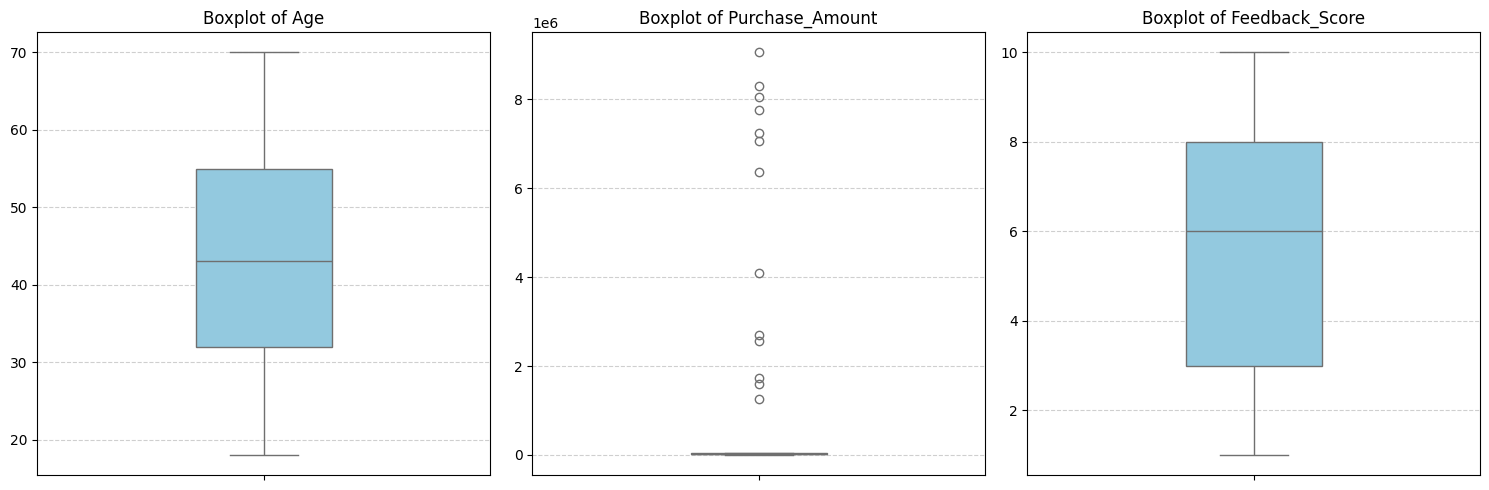

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

plt.figure(figsize=(15, 5))

for  i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color = 'skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize =12)
    plt.ylabel('')
    plt.grid(axis='y', linestyle ='--', alpha = 0.6)

plt.tight_layout()
plt.show()

In [85]:
from scipy import stats


In [86]:
stats.zscore(df[['Age', 'Purchase_Amount']])

array([[ 0.5822461 , -0.04365645],
       [ 0.51246898,  0.01755694],
       [ 1.28001721, -0.02657803],
       ...,
       [-0.6039648 ,  0.0152561 ],
       [-0.6039648 , -0.05353498],
       [-1.02262747,  0.01788172]], shape=(5738, 2))

In [89]:
import numpy as np
z_scores = np.abs(stats.zscore(df[['Age', 'Purchase_Amount']]))

In [91]:
df[(z_scores>3).any(axis = 1)]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
327,CUST3647,John\nHarris,male,50,pune,2023-03-16,2023-06-18,7755545.6,8.0,msdennis399@hotmail.com,2542863520,None
939,CUST1753,Melissa\nJackson,female,65,ahmedabad,2020-05-08,2022-05-08,8059234.9,8.0,berrynancy977@hotmail.com,3473405811,None
1042,CUST8724,Sarah\nThompson,female,43,jaipur,2021-02-12,2024-11-11,9057414.3,7.0,barrycrane513@gmail.com,2357227278,None
2518,CUST7853,Jessica\nWilson,male,40,ahmedabad,2018-08-02,2024-03-05,7245755.6,9.0,tara39674@outlook.com,8182045139,None
3078,CUST1509,Jennifer\nBrown,female,66,hyderabad,2023-02-16,2022-12-27,8299604.6,8.0,barrycrane670@hotmail.com,7243397447,None
3373,CUST4471,Robert\nWilson,male,55,hyderabad,2024-01-30,2021-05-01,2708963.4,9.0,tara39459@hotmail.com,1323291060,None
5908,CUST4163,Michael\nThompson,male,44,lucknow,2023-09-20,2022-10-20,6372319.1,2.0,berrynancy577@example.com,9283763073,None
5954,CUST2740,Jason\nLewis,male,35,jaipur,2021-08-16,2022-11-04,1254975.8,8.0,owensanthony605@example.com,2305438434,None
6613,CUST2766,Ashley\nMartin,female,43,kolkata,2020-05-05,2023-02-25,1596165.1,8.0,owensanthony688@gmail.com,2849775938,None
7448,CUST4268,Christopher\nThomas,male,37,hyderabad,2023-10-09,2025-02-04,2574796.9,1.0,berrynancy941@gmail.com,2136387524,None


In [92]:
df_clean = df[~(z_scores>3).any(axis = 1)]

In [93]:
df_clean.shape

(5725, 12)

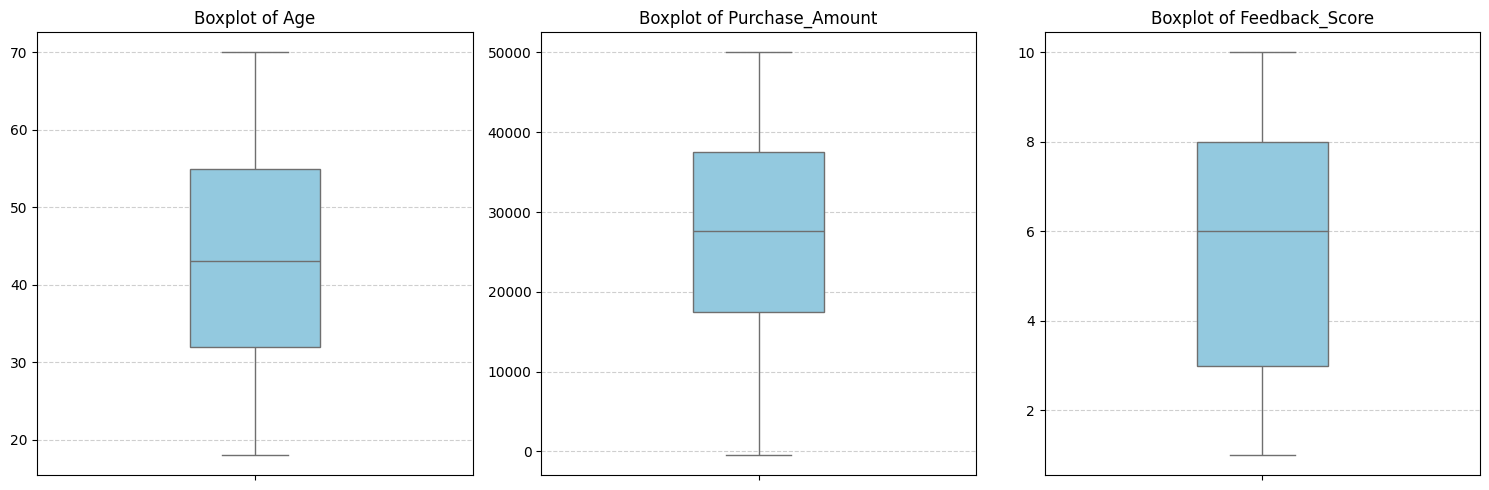

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

plt.figure(figsize=(15, 5))

for  i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_clean[col], color = 'skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize =12)
    plt.ylabel('')
    plt.grid(axis='y', linestyle ='--', alpha = 0.6)

plt.tight_layout()
plt.show()

In [95]:
df_clean.to_csv('clean customer sales data.csv')